In [2]:
pip install xgboost imbalanced-learn


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 728.2 kB/s eta 0:02:19
   ---------------------------------------- 0.8/101.7 MB 859.5 kB/s eta 0:01:58
   ---------------------------------------- 1.0/101.7 MB 868.0 kB/s eta 0:01:56
   ---------------------------------------- 1.0/101.7 MB 868.0 kB/s eta 0:01:56
   ---------------------------------------- 1.0/101.7 MB 868.0 kB/s eta 0:01:56
   ---------------------------------------- 1.0/101.7 MB 868.0 kB/s eta 0:01:56
   ---------------------------------------- 1.0/101.7 MB 868.0 kB/s eta 0:01:56
   ---------------------------------------- 1.0/101.7 MB 868.0 kB/s eta 0:01:56
   ---------------------------------------- 1.0/101.7 MB 868.0 kB/s eta 0:0

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, roc_auc_score

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [4]:
df = pd.read_csv("employee_attrition_cleaned.csv")

print(df.shape)
df.head()

(1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False


In [5]:
# Avoid divide by zero using +1

df["TenureRatio"] = df["YearsAtCompany"] / (df["TotalWorkingYears"] + 1)

df["IncomePerLevel"] = df["MonthlyIncome"] / (df["JobLevel"] + 1)

df["PromotionGap"] = df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1)

df["ManagerStability"] = df["YearsWithCurrManager"] / (df["YearsAtCompany"] + 1)

print("Feature engineering done ✅")

Feature engineering done ✅


In [6]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   
)

In [8]:
sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: Attrition
0    986
1    190
Name: count, dtype: int64
After SMOTE: Attrition
0    986
1    986
Name: count, dtype: int64


In [9]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='liblinear'
)

log_model.fit(X_train_sm, y_train_sm)

print("Logistic Regression trained ")

Logistic Regression trained 


In [10]:
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, roc_auc_score

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8537414965986394
Recall: 0.44680851063829785
F1 Score: 0.49411764705882355
ROC-AUC: 0.8122146610388491

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.93      0.91       247
           1       0.55      0.45      0.49        47

    accuracy                           0.85       294
   macro avg       0.73      0.69      0.70       294
weighted avg       0.84      0.85      0.85       294



In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_sm, y_train_sm)

print("Random Forest trained ")

Random Forest trained 


In [12]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.826530612244898
Recall: 0.2765957446808511
F1 Score: 0.33766233766233766
ROC-AUC: 0.7635455250236886

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       247
           1       0.43      0.28      0.34        47

    accuracy                           0.83       294
   macro avg       0.65      0.60      0.62       294
weighted avg       0.80      0.83      0.81       294



In [13]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,Recall,ROC-AUC
0,Logistic Regression,0.853741,0.446809,0.812215
1,Random Forest,0.826531,0.276596,0.763546


----
## Report (Selected LR)

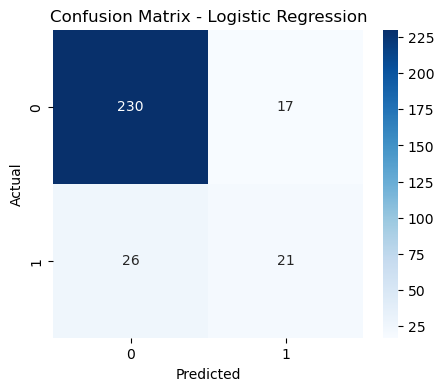

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

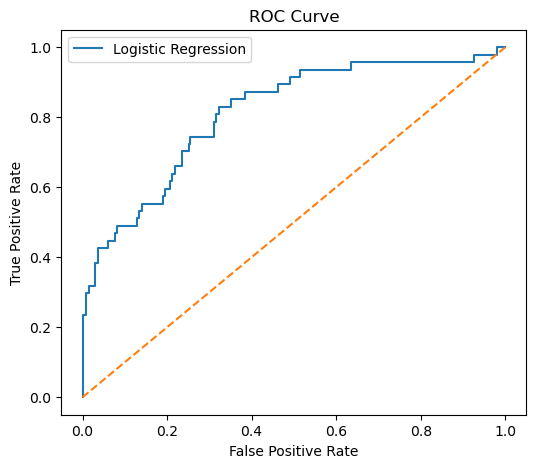

In [18]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

---
## Save the model 

In [19]:
log_model.fit(X_train_sm, y_train_sm)

LogisticRegression(class_weight='balanced', max_iter=2000, solver='liblinear')

In [20]:
import pickle

pickle.dump(log_model, open("model.pkl", "wb"))


In [21]:
pickle.dump(X.columns, open("feature_columns.pkl", "wb"))


---
## Performance Model Development

In [23]:
import pandas as pd

df = pd.read_csv("employee_attrition_cleaned.csv")

# Target
y_perf = df["PerformanceRating"]

# Features (recommended)
features = [
    "Education",
    "JobInvolvement",
    "JobLevel",
    "MonthlyIncome",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "TotalWorkingYears",
    "WorkLifeBalance"
]

X_perf = df[features]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_perf, y_perf, test_size=0.2, random_state=42
)

In [25]:
from sklearn.linear_model import LogisticRegression

perf_model = LogisticRegression(max_iter=1000)

perf_model.fit(X_train, y_train)

c:\Users\abish\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [26]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = perf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8537414965986394
              precision    recall  f1-score   support

           3       0.85      1.00      0.92       251
           4       0.00      0.00      0.00        43

    accuracy                           0.85       294
   macro avg       0.43      0.50      0.46       294
weighted avg       0.73      0.85      0.79       294



c:\Users\abish\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\abish\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\abish\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
import pickle

pickle.dump(perf_model, open("performance_model.pkl", "wb"))
pickle.dump(X_perf.columns, open("performance_features.pkl", "wb"))